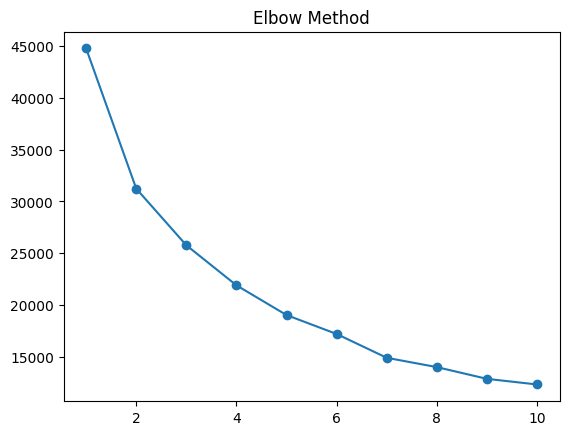

Silhouette Score: 0.40389035418208313


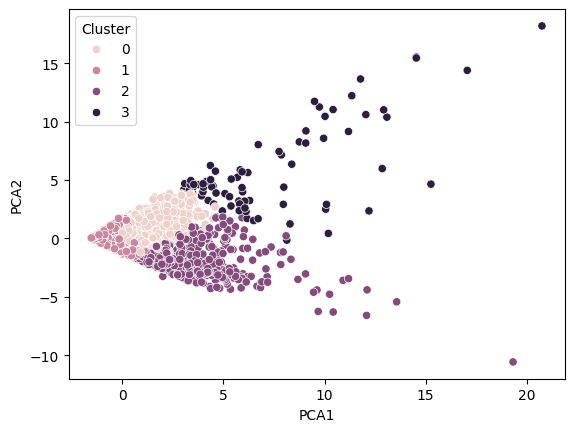

✅ Model Saved!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

# LOAD DATA
df = pd.read_csv("../dataset/credit_card.csv")

# DROP ID
df = df[[
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]]

# HANDLE MISSING
df.fillna(df.mean(), inplace=True)

# SCALE
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# ELBOW METHOD
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.show()

# MODEL (K=4)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

# SCORE
print("Silhouette Score:", silhouette_score(scaled_data, clusters))

# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df)
plt.show()

# SAVE MODEL
joblib.dump(kmeans, "../backend/model.pkl")
joblib.dump(scaler, "../backend/scaler.pkl")

print("✅ Model Saved!")